In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 120_000

dates = pd.date_range(start="2024-01-01", end="2024-06-30", freq="D")
cities = ["Almaty", "Astana", "Shymkent", "Other"]
segments = ["small", "medium", "large"]

# --- количество мерчантов по сегментам ---
merchants_by_segment = {
    "small": 5000,
    "medium": 1500,
    "large": 300
}

merchant_pool = []

for segment, cnt in merchants_by_segment.items():
    merchant_ids = [f"{segment}_{i}" for i in range(cnt)]
    merchant_pool.extend(
        [(m_id, segment) for m_id in merchant_ids]
    )

merchant_df = pd.DataFrame(
    merchant_pool,
    columns=["merchant_id", "merchant_segment"]
)

# --- генерируем платежи ---
payments = pd.DataFrame({
    "payment_id": np.arange(N),
    "date": np.random.choice(dates, N),
})

# случайно назначаем мерчанта платежу
payments = payments.merge(
    merchant_df.sample(N, replace=True).reset_index(drop=True),
    left_index=True,
    right_index=True
)

# город (привязан к платежу, упрощённо)
payments["city"] = np.random.choice(
    cities, N, p=[0.45, 0.25, 0.15, 0.15]
)

# --- способ оплаты ---
payments["payment_method"] = np.where(
    (payments["merchant_segment"] == "small") &
    (payments["city"] != "Almaty"),
    np.random.choice(["qr", "card"], N, p=[0.7, 0.3]),
    np.random.choice(["qr", "card"], N, p=[0.35, 0.65])
)

# --- сумма платежа ---
base_amount = {
    "small": 3500,
    "medium": 9000,
    "large": 22000
}

payments["amount"] = payments["merchant_segment"].map(base_amount)
payments["amount"] *= np.random.lognormal(mean=0, sigma=0.4, size=N)
payments["amount"] = payments["amount"].round(0)

def success_prob(row):
    if row["merchant_segment"] == "small":
        return 0.92 if row["payment_method"] == "qr" else 0.88
    if row["merchant_segment"] == "medium":
        return 0.95 if row["payment_method"] == "qr" else 0.93
    if row["merchant_segment"] == "large":
        return 0.98 if row["payment_method"] == "qr" else 0.97

payments["is_success"] = payments.apply(
    lambda row: np.random.rand() < success_prob(row),
    axis=1
).astype(int)

payments.head()

,payment_id,date,merchant_id,merchant_segment,city,payment_method,amount,is_success
0,0,2024-04-12,medium_1125,medium,Almaty,qr,21782.0,1
1,1,2024-06-28,small_1163,small,Other,qr,2069.0,1
2,2,2024-04-02,medium_807,medium,Almaty,card,12905.0,1
3,3,2024-01-15,small_1645,small,Shymkent,card,4315.0,1
4,4,2024-04-16,small_894,small,Shymkent,qr,4401.0,1


In [ ]:
len(payments)

120000

Kaspi.kz — экосистема, включающая:

- Kaspi Bank (платежи, кредиты)
- Kaspi Pay
- Kaspi Магазин

Ты аналитик в команде Kaspi Pay.
Команда заметила, что конверсия пользователей в успешный платёж вроде бы ухудшилась за последние месяцы, но бизнес уверен, что продукт стал лучше.

Твоя задача — разобраться в данных и объяснить, что происходит.

У тебя есть датафрейм payments, где каждая строка — попытка оплаты.

Колонки:

- payment_id — id платежа
- merchant_id — id пользователя
- date — дата платежа
- city — город мерчанта (Almaty, Astana, Shymkent, Other)
- merchant_segment — сегмент пользователя (small, medium, large)
- payment_method — способ оплаты (qr, card)
- amount — сумма платежа
- is_success — успешен ли платёж (1 — да, 0 — нет)

Дополнительно:

С января был запущен новый QR-флоу, который активнее подключали для small мерчантов и регионов.

Базовая разведка данных

Посчитай:

- общее количество платежей
- общую конверсию в успешный платёж
- средний чек успешных платежей

Проверь данные на:
- пропуски
- аномальные суммы (например, отрицательные или слишком большие)

In [ ]:
payments.payment_id.nunique()


120000

In [ ]:
#общую конверсию в успешный платёж
payments.is_success.mean()

np.float64(0.9122083333333333)

In [ ]:
tr = payments.query('is_success == 1').merchant_id.nunique()
tr

6800

In [ ]:
payments.isna().sum()

,0
payment_id,0
date,0
merchant_id,0
merchant_segment,0
city,0
payment_method,0
amount,0
is_success,0


In [ ]:
zero = payments.query('is_success == 0').merchant_id.nunique()
zero

5207

In [ ]:
unique_u = payments.merchant_id.nunique()
unique_u

6800

In [ ]:
conv = tr / unique_u
conv

1.0

In [ ]:
zero / unique_u

0.7657352941176471

In [ ]:
full_succ_cr = (tr - zero) /  unique_u

Базируясь на данных выше, можем сделать вывод:

1. Все пользователи, как минимум один раз, совершали успешный платеж. conv = 1
2. Количесво пользователей, которые совершали только успешные платежи состовляет full_succ_cr = 0.23

In [ ]:
#средний чек успешных платежей
payments.query('is_success == 1').amount.mean()

np.float64(6068.619312108894)

In [ ]:
payments.query('is_success == 1').amount.sum() / payments.query('is_success == 1').payment_id.nunique()

np.float64(6068.619312108894)

Средний чек, по успешным платежам составляет 6068.62

In [ ]:
payments[payments.isna().any(axis=1)]

,payment_id,date,merchant_id,merchant_segment,city,payment_method,amount,is_success


In [ ]:
#аномальные суммы
payments.amount.describe()

,amount
count,120000.000000
mean,5972.191608
std,5514.411305
min,507.000000
25%,2958.000000
50%,4177.000000
75%,6721.000000
max,97183.000000


Благодаря .describe() - можно увидеть, что есть, какие-то суммы, которые явно сдвигают данные.

Медиана = 4177. Среднее значение = 5972

Q3 (75%) = 6721. max = 97183

Базируясь уже на этих данных, понятно, что нужно выявить данные ближайших max и min значений и уточнить - это ошибка, или просто большой/маленький заказ, который нужно иметь ввиду, но не исправлять

In [ ]:
#Ищем 10 max значений
payments.sort_values('amount', ascending = False).head(10)

,payment_id,date,merchant_id,merchant_segment,city,payment_method,amount,is_success
88739,88739,2024-02-17,large_116,large,Other,card,97183.0,1
80094,80094,2024-03-17,large_295,large,Astana,card,95419.0,1
118747,118747,2024-03-01,large_90,large,Astana,card,86520.0,1
84747,84747,2024-03-19,large_72,large,Astana,card,80089.0,1
30406,30406,2024-03-08,large_165,large,Almaty,card,77391.0,1
96258,96258,2024-04-14,large_280,large,Other,qr,76427.0,1
11033,11033,2024-06-13,large_80,large,Almaty,qr,75703.0,1
23155,23155,2024-03-25,large_70,large,Shymkent,card,75451.0,1
36341,36341,2024-02-08,large_77,large,Astana,qr,75176.0,1
85876,85876,2024-06-29,large_41,large,Astana,card,74679.0,1


In [ ]:
#Ищем 10 min значений
payments.sort_values('amount').head(10)

,payment_id,date,merchant_id,merchant_segment,city,payment_method,amount,is_success
45126,45126,2024-06-03,small_2371,small,Almaty,card,507.0,1
108154,108154,2024-05-15,small_2015,small,Almaty,qr,645.0,1
2429,2429,2024-02-29,small_2262,small,Other,card,662.0,1
12777,12777,2024-06-21,small_651,small,Astana,qr,699.0,0
118661,118661,2024-01-02,small_268,small,Other,qr,743.0,1
105248,105248,2024-04-01,small_2417,small,Almaty,card,764.0,1
62773,62773,2024-01-25,small_3173,small,Shymkent,card,782.0,1
102300,102300,2024-04-05,small_2373,small,Almaty,card,786.0,1
25864,25864,2024-01-18,small_4593,small,Shymkent,qr,788.0,1
31231,31231,2024-05-12,small_1115,small,Almaty,qr,790.0,1


Посмотрев данные по каждому сегменту, и сравнив их 10-max и 10-min значений (подтверждения в черновике), можно выделить сегмент large, с большим отрывом по amount, в верхнем регистре.

Поэтому есть предложение отсеить 10% верхних значений и 10% нижних, чтобы стабилизировать показатели среднего значения. Либо при рассчетах учитывать момент, что в 'large segment' - есть большие заказы

<Axes: xlabel='merchant_segment', ylabel='amount'>

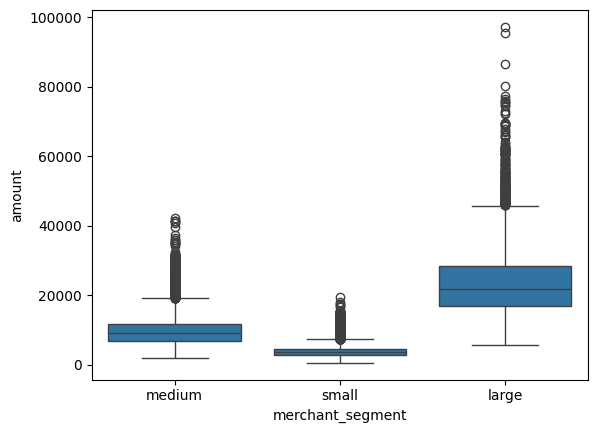

In [ ]:
import seaborn as sns
sns.boxplot(data = payments, x = 'merchant_segment', y = 'amount')

На графике выше, можно увидеть, что есть много outliners, в особенности выделяются 4-е верхних в сегменте 'large'

**Итог по блоку:**

* общее количество платежей: 120 000
* общая конверсия успешных платёжей: 1.0
* общая конверсия тех у кого Только успешные платежи: 0.23
* средний чек успешных платежей: 6068.72
* NaN значения - отсутствуют
* Аномальные amount - в сегменте large есть значения сильно влияющие на средние показатели (полное док. в черновике)

In [ ]:
#####

Общая динамика конверсии

- Посчитай дневную или месячную конверсию платежей (is_success)
- Построй линейный график конверсии во времени с помощью matplotlib

In [ ]:
#Посчитай дневную конверсию платежей (is_success)
day_suc_pay = (payments
               .groupby('date')
               .agg(
                   cnt_payment_suc = ('is_success', 'count'),
                   cr = ('is_success', 'mean')
               )
               .reset_index())

day_suc_pay

,date,cnt_payment_suc,cr
0,2024-01-01,650,0.912308
1,2024-01-02,669,0.913303
2,2024-01-03,682,0.914956
3,2024-01-04,698,0.909742
4,2024-01-05,682,0.898827
...,...,...,...
177,2024-06-26,668,0.917665
178,2024-06-27,650,0.904615
179,2024-06-28,680,0.895588
180,2024-06-29,640,0.914062


In [ ]:
#Посчитай месячную конверсию платежей (is_success)
month_cnt_payment = (payments
                     .groupby(payments.date.dt.month)
                     .agg(
                         cnt_payment = ('is_success', 'count'),
                         cr = ('is_success', 'mean')
                      )
                     .reset_index())
month_cnt_payment


,date,cnt_payment,cr
0,1,20641,0.911729
1,2,18768,0.914056
2,3,20466,0.909215
3,4,19931,0.911846
4,5,20367,0.912947
5,6,19827,0.913653


In [ ]:
#Недельная конверсия
week_cnt_payment = (payments
                     .groupby(payments.date.dt.to_period('W'))
                     .agg(
                         cnt_payment = ('is_success', 'count'),
                         cr = ('is_success', 'mean')
                      )
                     .reset_index())
week_cnt_payment

,date,cnt_payment,cr
0,2024-01-01/2024-01-07,4702,0.909188
1,2024-01-08/2024-01-14,4630,0.912743
2,2024-01-15/2024-01-21,4588,0.914124
3,2024-01-22/2024-01-28,4683,0.912022
4,2024-01-29/2024-02-04,4555,0.914819
5,2024-02-05/2024-02-11,4547,0.916428
6,2024-02-12/2024-02-18,4563,0.912119
7,2024-02-19/2024-02-25,4502,0.912483
8,2024-02-26/2024-03-03,4635,0.906149
9,2024-03-04/2024-03-10,4557,0.906298


<Axes: xlabel='date'>

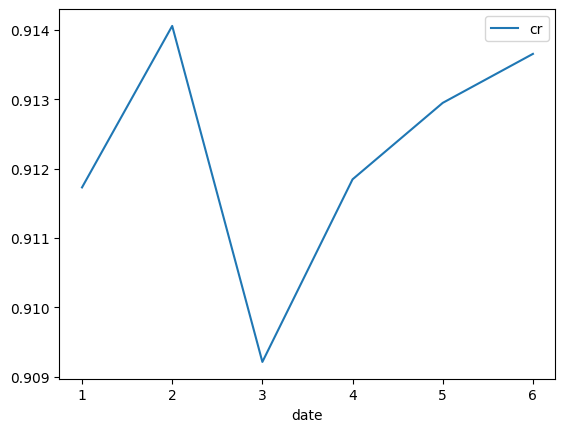

In [ ]:
month_cnt_payment.plot(x = 'date', y = 'cr')


<Axes: xlabel='date'>

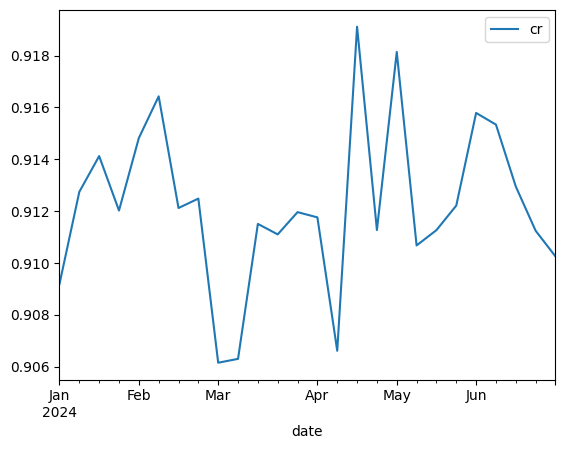

In [ ]:
week_cnt_payment.plot(x = 'date', y = 'cr')


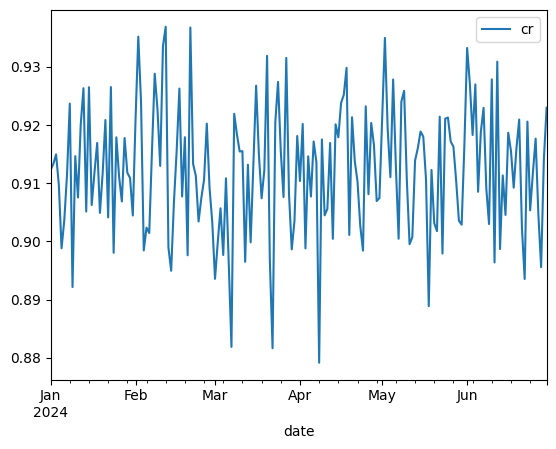

In [ ]:
plot = day_suc_pay.plot(x = 'date', y = 'cr')


**Итоги по блоку:**

Выше приведены два вида графиков. Под увелечит. стеклом и реальный диапозон от 1 до 100.

* Посмотрев на все 3 диапазона (месячный, недельный, дневной) можно обратить внимание на месяц и более конкретные даты, когда кол-во успешных процедур значительно меньше. Хочу выделить начало Марта и начало Апреля
*  А так же месяцы, когда кол-во успешных платежей стало выше обычного. Это середина Апреля и начало Мая.
* Но если посмотреть реальный диапазон, то месячный держится стабильно cr = 91.
А дневной колеблится от 88 - 93. Но cr.mean(), конечно остается 91

* Можно провести доп. анализ и выявить конверсию по is_success внутри сегментов, что может ответить на некоторые вопросы. Такие как, возможно ли, что в small сегменте меньше процент успешных операций и кол-во заказов по этому сегменту может рушить статистику?

В целом, т.к. время у меня есть, почему бы и нет

In [ ]:
payments_merch_cr = (payments
                     .groupby('merchant_segment')
                     .agg(
                         cnt_orders = ('is_success', 'count'),
                         cr = ('is_success', 'mean')
                      )
                     .reset_index())

payments_merch_cr

,merchant_segment,cnt_orders,cr
0,large,5243,0.975396
1,medium,26579,0.937093
2,small,88178,0.900950


Можно обратить внимание, что кол-во заказов в сегменте small значительно выше в сравнении с другими (что логично) и они являются одними из возможных показателей, которые могут влиять на статистику успешных показателей.

Сюда также может (возможно, это только предположения) входить моменты:

* Сезон (что я показал выше, но, чтобы быть уверенным нужны данные прошлого года)
* Конкретные Заказчики
* Город
* Способ оплаты

До конца не могу быть уверенным, т.к. еще не был проведен весь анализ

In [ ]:
#####

Конверсия по способу оплаты

Посчитай конверсию отдельно для:
- qr
- card

Сравни:
- долю платежей
- конверсию

Приведи нужные графики

Ответь на вопрос: Правда ли, что QR работает хуже карт?

In [ ]:
#Посчитай конверсию отдельно для: qr
payment_cnt = (payments
              .groupby('payment_method')
              .agg(
                  cnt_payment = ('is_success', 'count'),
                  cr = ('is_success', 'mean')
              )
              .reset_index())
payment_cnt

,payment_method,cnt_payment,cr
0,card,61023,0.897842
1,qr,58977,0.927073


NameError: name 'plt' is not defined

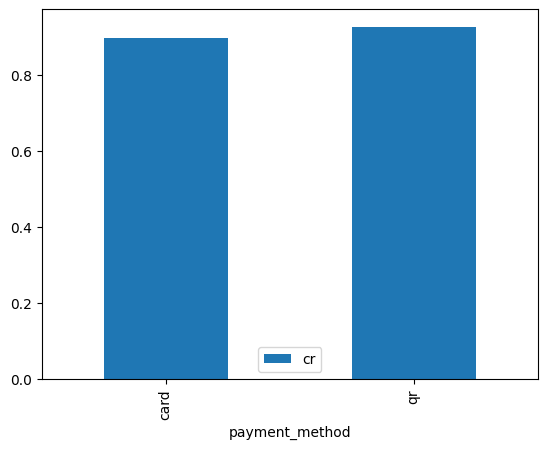

In [ ]:
#график по конверсии
payment_cnt.plot(x = 'payment_method', y = 'cr', kind = 'bar')


<Axes: xlabel='payment_method'>

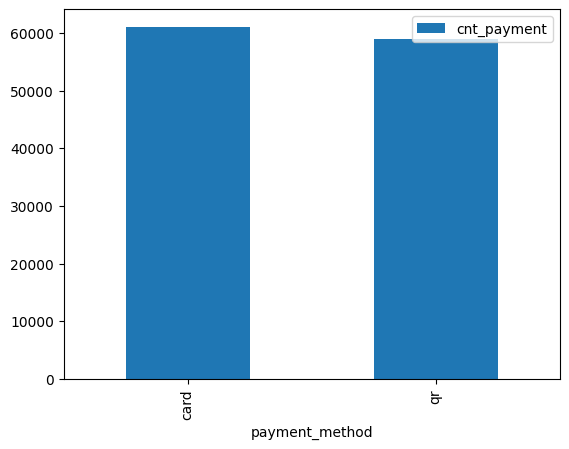

In [ ]:
#Доли платежей
payment_cnt.plot(x = 'payment_method', y = 'cnt_payment', kind = 'bar')


**Но вопрос должен возникать иной**. А как менялась конверсия по способу оплаты за последние месяцы?

Давайте посмотрим

In [ ]:
#Я понимаю, что в таблице инфа за один год, но стоит привыкать, что чаще работешь с периодом больше года
payments['month'] = payments.date.dt.to_period('M')

In [ ]:
cr_payments_by_month = (
    payments
    .pivot_table(
        index = 'month',
        columns = 'payment_method',
        values = 'is_success',
        aggfunc = 'mean',
        fill_value=0
    )
)

cr_payments_by_month

payment_method,card,qr
month,,
2024-01,0.897862,0.926021
2024-02,0.896563,0.932148
2024-03,0.896374,0.922692
2024-04,0.898938,0.925300
2024-05,0.899480,0.926961
2024-06,0.897763,0.929716


In [ ]:
share_payments_by_month = (
    payments
    .pivot_table(
        index = 'month',
        columns = 'payment_method',
        values = 'is_success',
        aggfunc = 'count',
        fill_value=0
    )
)

share_payments_by_month

payment_method,card,qr
month,,
2024-01,10476,10165
2024-02,9542,9226
2024-03,10480,9986
2024-04,10172,9759
2024-05,10386,9981
2024-06,9967,9860


<Axes: xlabel='month'>

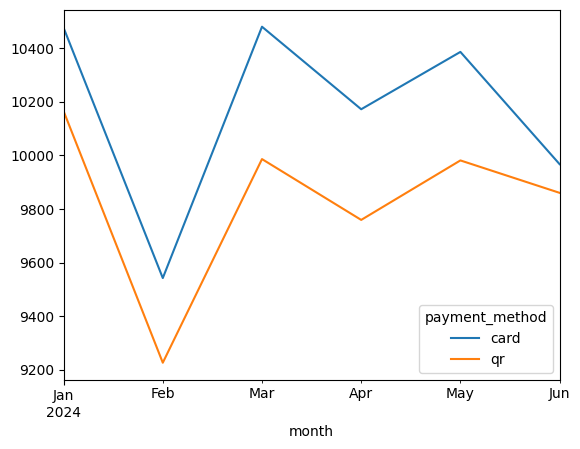

In [ ]:
#Кол-во платежей за последние месяцы
share_payments_by_month.plot()

<Axes: xlabel='month'>

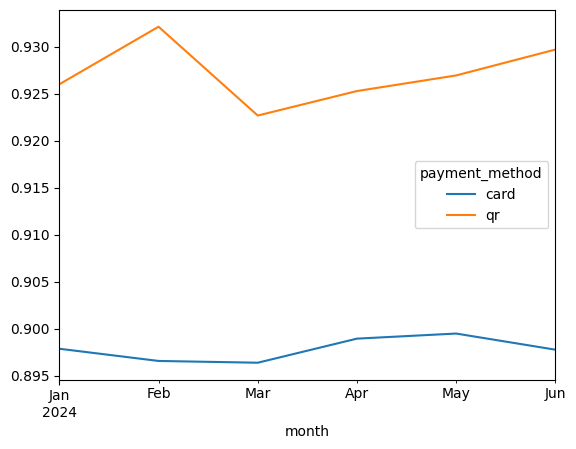

In [ ]:
#Конверсия по успешным платежам за последние месяцы
cr_payments_by_month.plot()

**Итог по блоку:**

* Стоит обратить внимание, что общая конверсия у 'qr' лучше, на 3%
* Но и разница операций, у card - оно выше, на ~2000
* Если посмотреть конверсию у способов оплаты с начала 2024 года, то можно увидеть, что конверсия по успешным платежам у qr, с периода его открытия, выше  

Значимость показателей конверсии подтверждается кол-ом попыток оплаты. Но базируясь только на этих данных я не могу утверждать, что 'qr' 100% лучше 'card'. Но, вероятно, при увеличении кол-ва операций по 'qr' - показатели общей конверсии могут улучшиться.

Если данный вывод дополнить тем, что доля по qr выросла, за последний месяц, а вместе с ней и ее cr, то причина явно не только в способе оплаты


In [ ]:
#####

Конверсия по сегментам мерчантов

Посчитай конверсию:
- по merchant_segment
- по payment_method внутри сегмента

Отсортируй сегменты по объему платежей

Приведи нужные графики

Для каких мерчантов QR действительно хуже, а для каких — лучше?

In [ ]:
#Посчитай конверсию: по merchant_segment
merch_cnt = (payments
             .groupby('merchant_segment')
             .agg(
                  cnt_merchant = ('is_success', 'count'),
                  cr = ('is_success', 'mean')
             )
             .reset_index())


merch_cnt

,merchant_segment,cnt_merchant,cr
0,large,5243,0.975396
1,medium,26579,0.937093
2,small,88178,0.900950


In [ ]:
#по payment_method внутри сегмента
merch_cnt_paymet = (payments
                    .groupby(['merchant_segment', 'payment_method'])
                    .agg(cnt_merchant_by_paymet = ('is_success', 'count'),
                         cr = ('is_success', 'mean')
                      )
                    .sort_values('cnt_merchant_by_paymet')
                    )
#Я не делал reset_index(), т.к. мне показалось, что так данные лучше читаются
merch_cnt_paymet

cnt_merchant_by_paymet        cr
merchant_segment payment_method                                  
large            qr                                1860  0.980108
                 card                              3383  0.972805
medium           qr                                9177  0.951400
                 card                             17402  0.929548
small            card                             40238  0.877827
                 qr                               47940  0.920359

<Axes: ylabel='cnt_merchant'>

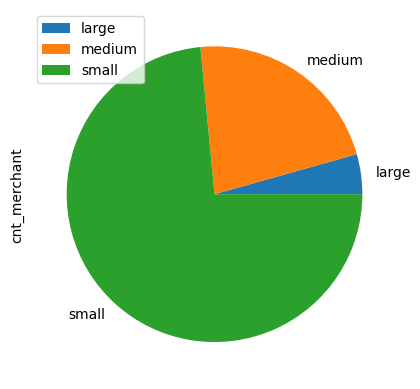

In [ ]:
#Доли по сегментам
merch_cnt.plot(kind = 'pie', y = 'cnt_merchant', labels = merch_cnt.merchant_segment)

<Axes: xlabel='merchant_segment'>

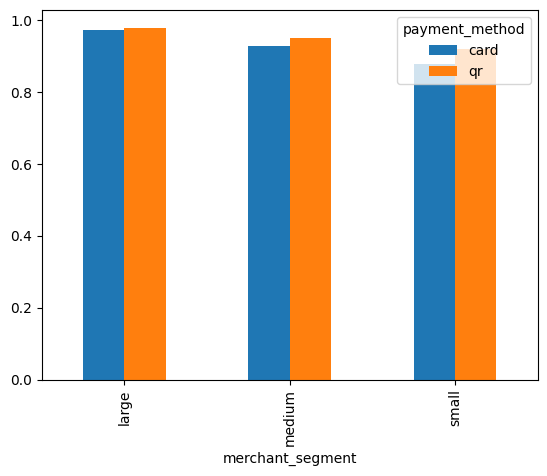

In [ ]:
#Приведм график разницы между qr и card внутри сегментов
res_merch_cnt_paymet = merch_cnt_paymet.reset_index()

#Сделаем через pivot для лучшего отоброжения значений
pivot_1 = res_merch_cnt_paymet.pivot_table(
    index='merchant_segment',
    columns='payment_method',
    values='cr',
)

pivot_1.plot(kind = 'bar')


<Axes: xlabel='merchant_segment'>

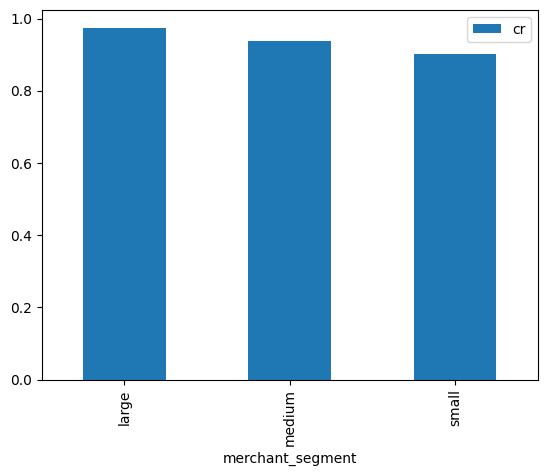

In [ ]:
#График показывает на какой сегмент падает наибольшее кол-во заказов
merch_cnt.plot(x = 'merchant_segment', y = 'cr', kind = 'bar')


Не могу пройти мимо и не сравнить конверсию и доли за последние месяцы, с открытия qr

In [ ]:
merch_share_month = (
    payments
    .pivot_table(
        index = 'month',
        columns = 'merchant_segment',
        values = 'is_success',
        aggfunc = 'count',
        fill_value=0
    )
)
merch_share_month

merchant_segment,large,medium,small
month,,,
2024-01,903,4642,15096
2024-02,838,4116,13814
2024-03,919,4385,15162
2024-04,820,4376,14735
2024-05,878,4567,14922
2024-06,885,4493,14449


In [ ]:
merch_cr_month = (
    payments
    .pivot_table(
        index = 'month',
        columns = 'merchant_segment',
        values = 'is_success',
        aggfunc = 'mean',
        fill_value=0
    )
)
merch_cr_month

merchant_segment,large,medium,small
month,,,
2024-01,0.965670,0.937312,0.900636
2024-02,0.982100,0.935374,0.903576
2024-03,0.982590,0.933181,0.897837
2024-04,0.976829,0.937157,0.900713
2024-05,0.971526,0.941756,0.900684
2024-06,0.974011,0.937458,0.902554


In [ ]:
merch_cr_month = (
    payments
    .pivot_table(
        index = 'month',
        columns = ['merchant_segment', 'payment_method'],
        values = 'is_success',
        aggfunc = 'mean',
        fill_value=0
    )
)
merch_cr_month

merchant_segment     large              medium               small          
payment_method        card        qr      card        qr      card        qr
month                                                                       
2024-01           0.962264  0.971875  0.928454  0.954009  0.878863  0.918771
2024-02           0.979206  0.987055  0.931502  0.943001  0.874423  0.927898
2024-03           0.983361  0.981132  0.925078  0.948735  0.877073  0.915626
2024-04           0.978558  0.973941  0.931992  0.947122  0.878855  0.919326
2024-05           0.967410  0.979661  0.932460  0.959145  0.879303  0.918715
2024-06           0.966899  0.987138  0.927881  0.954859  0.878214  0.922429

<Axes: xlabel='month'>

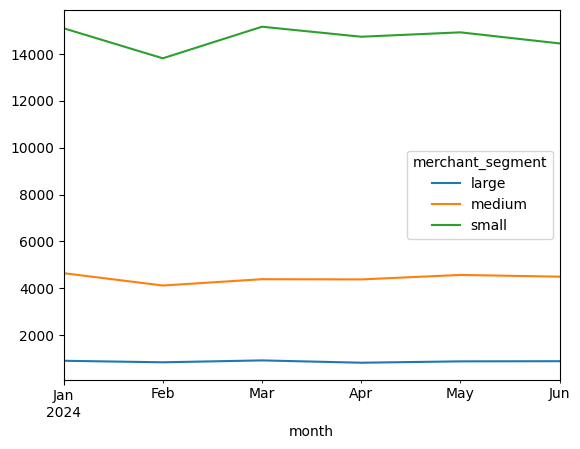

In [ ]:
#Изменение доли платежей по сегментам в разне месяца
merch_share_month.plot()

<Axes: xlabel='month'>

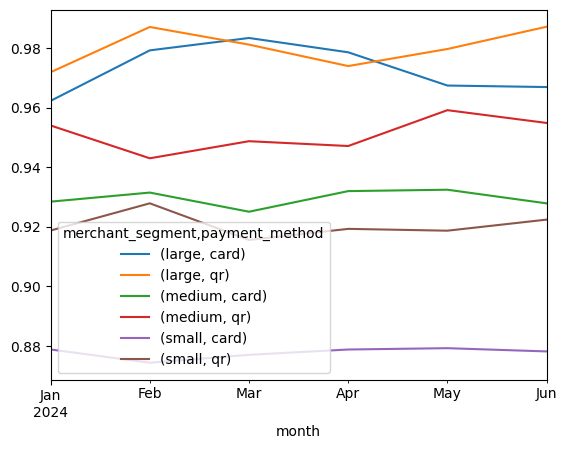

In [ ]:
#Разница конверсии по успешным платежам за последние месяцы
merch_cr_month.plot()

<Axes: xlabel='month'>

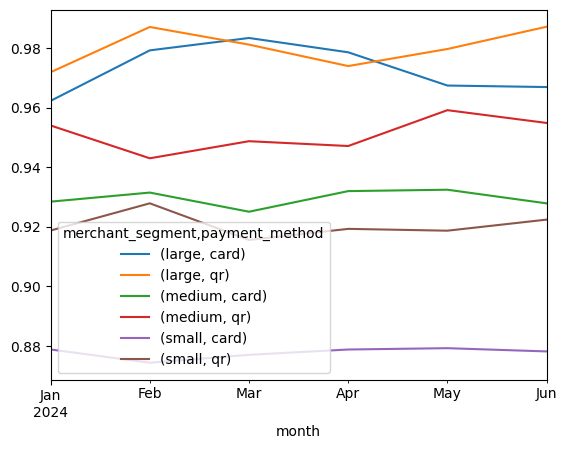

In [ ]:
#Ахахаха, пздц, все-понятно)))))))
#Изменение конверсии по сегментам и способу оплаты в разные месяцы
merch_cr_month.plot()

**Итоги по блоку:**
1. По графикам можно увидеть, разницу конверсии по способу оплаты, внутри сегментов.
* Для 'large' сегмента, разница конверсии успешных платежей по способу оплаты составляет менее 1%, в пользу qr
* Но для 'medium' и 'small' - 2% и 4%, в пользу qr, что значительно выше

На вопрос 'Для каких мерчантов QR действительно хуже, а для каких — лучше?' - ответ сводится к тому, что qr лучше для всех сегментов, но в рамках этого вопроса

2. Также не могу пропустить, что кол-во операций значительно преобладают в small. Но также, не стоит забывать про разницу amount между ними
3. Без учета последнего графика)
Хочу обратить внимание, что кол-во платеже по сегментам, за последний месяц была практически не изменной. Кол-во платежей в 'small' сегменте уменьшилась, и также вместе с ней улучшилась конверсия в это области.

Но, следует обратить внимание, что доля по платежам в областях medium и large, за последние месяцы, была неизменной (что странно). А кол-во успешных платежей значительно снизилась (для medium - за последний месяц. для large - за последние 4 месяца, хоть и в последнем пошла на повышение)




In [ ]:
#####

Посчитай конверсию:

- по городам
- отдельно для QR

Найди города, где:
- QR сильно проседает
- QR наоборот лучше карт

In [ ]:
#Посчитай конверсию:по городам
city_cr = (payments
           .groupby('city')
           .agg(
               cnt_orders = ('payment_id', 'count'),
               cr = ('is_success', 'mean')
            )
           .reset_index()
           )

city_cr

,city,cnt_orders,cr
0,Almaty,53748,0.904908
1,Astana,30197,0.916747
2,Other,18219,0.920083
3,Shymkent,17836,0.918479


In [ ]:
#Решил сделать по paym. чтобы лучше увидеть разницу
city_qr_cr = (payments.groupby(['city', 'payment_method'])
              .agg(cnt_orders = ('is_success', 'count'),
                   cr = ('is_success', 'mean'))
              .reset_index())
city_qr_cr

,city,payment_method,cnt_orders,cr
0,Almaty,card,35112,0.892686
1,Almaty,qr,18636,0.927935
2,Astana,card,11835,0.904351
3,Astana,qr,18362,0.924736
4,Other,card,7137,0.907104
5,Other,qr,11082,0.928443
6,Shymkent,card,6939,0.903300
7,Shymkent,qr,10897,0.928145


<Axes: ylabel='cnt_orders'>

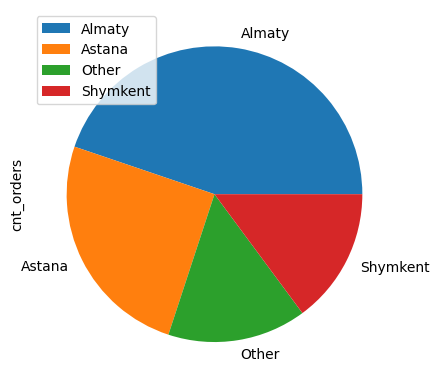

In [ ]:
#График долей городов
city_cr.plot(labels = city_cr.city, y = 'cnt_orders', kind = 'pie')

<Axes: xlabel='city'>

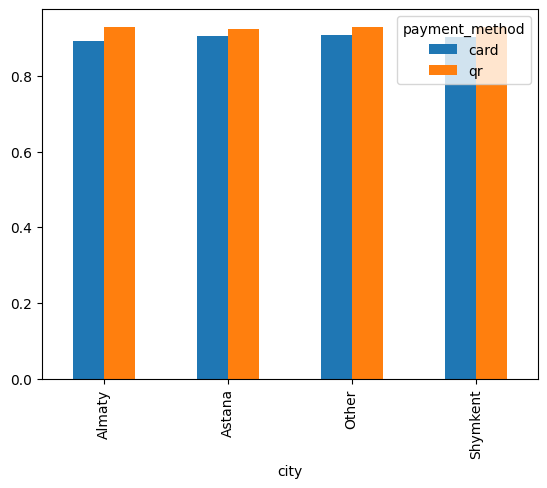

In [ ]:
#График по разнице способов оплаты внутри городов

pivot = city_qr_cr.pivot(
    columns = 'payment_method',
    index = 'city',
    values = 'cr'
)

pivot.plot(kind = 'bar')

Что на счет изменения по месяцам?)

In [ ]:
city_cr_month = (
    payments.
    pivot_table(
        index = 'month',
        columns = 'city',
        values = 'is_success',
        aggfunc = 'mean',
        fill_value=0
    )
)
city_cr_month

city,Almaty,Astana,Other,Shymkent
month,,,,
2024-01,0.902078,0.918348,0.925142,0.916496
2024-02,0.908874,0.917532,0.916348,0.921393
2024-03,0.900043,0.912714,0.923321,0.916504
2024-04,0.903837,0.916262,0.919613,0.920369
2024-05,0.908374,0.916214,0.917932,0.915810
2024-06,0.906752,0.919448,0.917550,0.920667


In [ ]:
city_cnt_month = (
    payments.
    pivot_table(
        index = 'month',
        columns = 'city',
        values = 'is_success',
        aggfunc = 'count',
        fill_value=0
    )
)
city_cnt_month

city,Almaty,Astana,Other,Shymkent
month,,,,
2024-01,9385,5156,3166,2934
2024-02,8384,4717,2881,2786
2024-03,9214,5018,3156,3078
2024-04,8860,5147,2998,2926
2024-05,9004,5156,3095,3112
2024-06,8901,5003,2923,3000


In [ ]:
city_method_cr_month = (
    payments.
    pivot_table(
        index = 'month',
        columns = ['city', 'payment_method'],
        values = 'is_success',
        aggfunc = 'mean',
        fill_value=0
    )
)
city_method_cr_month

city              Almaty              Astana               Other            \
payment_method      card        qr      card        qr      card        qr   
month                                                                        
2024-01         0.889143  0.926380  0.904040  0.927267  0.919838  0.928534   
2024-02         0.894622  0.936111  0.900055  0.928522  0.899393  0.927662   
2024-03         0.890438  0.918182  0.907584  0.916089  0.908279  0.932952   
2024-04         0.892993  0.924331  0.906128  0.923002  0.903697  0.929700   
2024-05         0.897119  0.929768  0.898239  0.928021  0.909688  0.923282   
2024-06         0.892108  0.933673  0.909933  0.925490  0.900528  0.928372   

city            Shymkent            
payment_method      card        qr  
month                               
2024-01         0.910211  0.920467  
2024-02         0.897556  0.936121  
2024-03         0.895377  0.930623  
2024-04         0.911130  0.926429  
2024-05         0.902778  0.924258  
2024-06         0.902939  0.931273

<Axes: xlabel='month'>

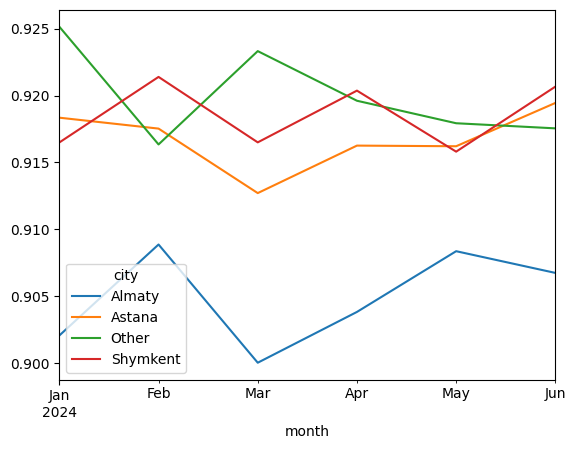

In [ ]:
city_cr_month.plot()

<Axes: xlabel='month'>

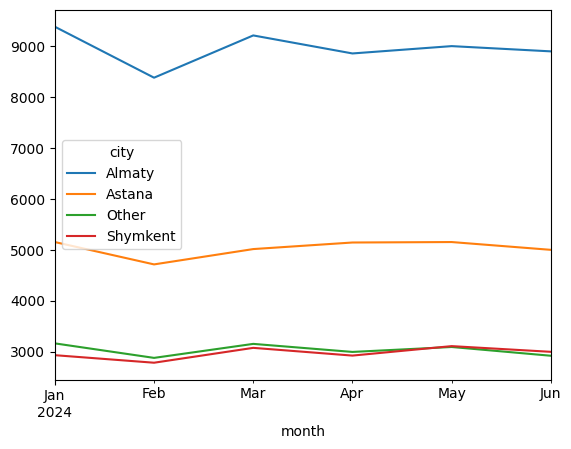

In [ ]:
#Изменение кол-ва попыток оплаты по городам, за помледние ме
city_cnt_month.plot()

<Axes: xlabel='month'>

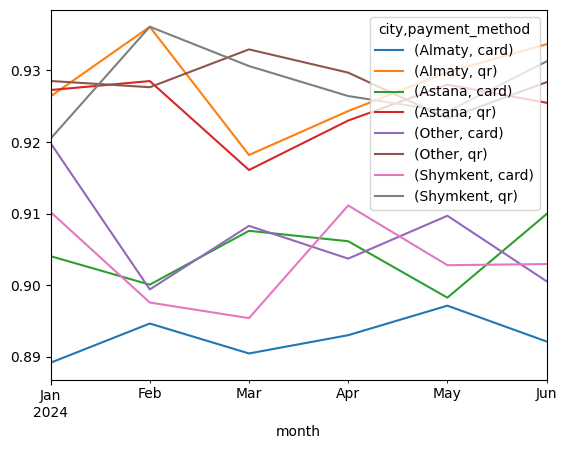

In [ ]:
#Изменение cr по городам и способам оплаты, за последние месяцы (нам нужны только Almaty)
city_method_cr_month.plot()

**Итоги по сравнению cr:**
Обращая внимание на последние графики, могу предроложить, что на изменение конверсии по успешным платежам повлияли:
1. Постепенное снижение cr в Алматы:
* Снижение замечено у card, у qr - рост (за последний месяц)
2. Постепенное снижение cr в medium сегменте:
* Снижается cr, как в qr, так и в card. Но все же cr у qr выше  
